In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
file_path = r'C:\Users\sharif\Desktop\Final5.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""METHANOL"").F","STREAMS(""METHANOL"").T","STREAMS(""METHANOL"").P","STREAMS(""FV"").F","STREAMS(""FV"").T","STREAMS(""FV"").P","STREAMS(""FV"").Zmn(""1-BUT-01"")","STREAMS(""FV"").Zmn(""ISOBU-01"")","STREAMS(""P1"").F","STREAMS(""P1"").T",...,"BLOCKS(""RDCOLUMN"").Stage(4).T","BLOCKS(""RDCOLUMN"").Stage(5).T","BLOCKS(""RDCOLUMN"").Stage(6).T","BLOCKS(""RDCOLUMN"").Stage(7).T","BLOCKS(""RDCOLUMN"").Stage(8).T","BLOCKS(""RDCOLUMN"").Stage(9).T","BLOCKS(""RDCOLUMN"").Stage(10).T","BLOCKS(""RDCOLUMN"").Stage(11).T","STREAMS(""P1"").Zmn(""1-BUT-01"")","STREAMS(""P2"").Zmn(""METHY-01"")"
0,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
1,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
2,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
3,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
4,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3313,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974


In [3]:
x = df.iloc[:, :-2].values
y = df.iloc[:, -2:].values

In [4]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
x = scaler_x.fit_transform(x)
y = scaler_y.fit_transform(y)

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
class MyDataset(Dataset):
    def __init__(self, data, label):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.label = torch.tensor(label, dtype=torch.float32)
    def __getitem__(self, index):
        return self.data[index], self.label[index]
    def __len__(self):
        return len(self.data)

In [7]:
train_dataset = MyDataset(x_train, y_train)
test_dataset = MyDataset(x_test, y_test)

In [8]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
import torch.nn as nn
import torch.nn.functional as F

In [10]:
class AutoEncoder(nn.Module):
    def __init__(self, dim_X, dim_H):
        super().__init__()
        self.encoder = nn.Linear(dim_X, dim_H)
        self.decoder = nn.Linear(dim_H, dim_X + 2)
        self.act = torch.sigmoid

    def forward(self, x, rep=False):
        h = self.act(self.encoder(x))
        return h if rep else self.act(self.decoder(h))

In [11]:
class GatedSAE(nn.Module):
    def __init__(self, layer_sizes, device):
        super().__init__()
        self.layers = nn.ModuleList([AutoEncoder(layer_sizes[i], layer_sizes[i+1]) for i in range(len(layer_sizes)-1)])
        self.device = device
        self.Wg = nn.ParameterList([nn.Parameter(torch.ones(h, 2).to(device)*0.0005) for h in layer_sizes[1:]])
        self.bg = nn.ParameterList([nn.Parameter(torch.zeros(2).to(device)) for _ in layer_sizes[1:]])
        self.Wt = nn.ParameterList([nn.Parameter(torch.ones(h, 2).to(device)*0.0005) for h in layer_sizes[1:]])
        self.bt = nn.ParameterList([nn.Parameter(torch.zeros(2).to(device)) for _ in layer_sizes[1:]])

    def gate_unit(self, H, Wg, bg, Wt, bt):
        g = torch.sigmoid(H @ Wg + bg)
        t = torch.tanh(H @ Wt + bt)
        return g * t

    def forward(self, x):
        out = x
        gated_outputs = []
        for i, ae in enumerate(self.layers):
            out = ae(out, rep=True)
            gated = self.gate_unit(out, self.Wg[i], self.bg[i], self.Wt[i], self.bt[i])
            gated_outputs.append(gated)
        return sum(gated_outputs)

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = x.shape[1]
model = GatedSAE(layer_sizes=[input_dim, 64, 32, 16], device=device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

epochs = 500
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss = {total_loss:.6f}")

Epoch 1, Loss = 127.692265
Epoch 2, Loss = 72.147199
Epoch 3, Loss = 49.509420
Epoch 4, Loss = 38.090607
Epoch 5, Loss = 33.319295
Epoch 6, Loss = 31.130966
Epoch 7, Loss = 29.878417
Epoch 8, Loss = 28.656090
Epoch 9, Loss = 27.776765
Epoch 10, Loss = 27.040978
Epoch 11, Loss = 26.455676
Epoch 12, Loss = 25.780229
Epoch 13, Loss = 25.317517
Epoch 14, Loss = 25.211680
Epoch 15, Loss = 24.979305
Epoch 16, Loss = 24.397944
Epoch 17, Loss = 24.188929
Epoch 18, Loss = 23.846875
Epoch 19, Loss = 23.895064
Epoch 20, Loss = 23.516115
Epoch 21, Loss = 23.557066
Epoch 22, Loss = 23.184630
Epoch 23, Loss = 23.396504
Epoch 24, Loss = 23.108288
Epoch 25, Loss = 23.047541
Epoch 26, Loss = 23.005797
Epoch 27, Loss = 22.765247
Epoch 28, Loss = 22.750882
Epoch 29, Loss = 22.705915
Epoch 30, Loss = 22.671803
Epoch 31, Loss = 22.599947
Epoch 32, Loss = 22.683903
Epoch 33, Loss = 22.678096
Epoch 34, Loss = 22.519735
Epoch 35, Loss = 23.057706
Epoch 36, Loss = 22.443101
Epoch 37, Loss = 22.458237
Epoch 38,

In [13]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_true, y_pred = [], []
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        y_pred.append(pred)
        y_true.append(yb.numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

In [14]:
y_true_inv = scaler_y.inverse_transform(y_true)
y_pred_inv = scaler_y.inverse_transform(y_pred)

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true_inv, y_pred_inv)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

In [16]:
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

MSE: 0.00039649615064263344
MAE: 0.002610614523291588
R2 Score: 0.8695026636123657


In [17]:
import csv

In [18]:
results = np.hstack([y_true_inv, y_pred_inv])

In [19]:
header = ['True_BOT', 'True_DIS', 'Pred_BOT', 'Pred_DIS']
output_file = 'Gated_SAE_Results.csv'

In [20]:
with open(output_file, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(results)

print(f"{output_file}")

Gated_SAE_Results.csv


In [21]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [22]:
tolerances = [0.005, 0.002, 0.001]

# دو خروجی داریم: TX (ستون 0) و HX (ستون 1)
tx_true = y_true_inv[:, 0]
tx_pred = y_pred_inv[:, 0]
hx_true = y_true_inv[:, 1]
hx_pred = y_pred_inv[:, 1]

tx_results = []
hx_results = []

In [23]:
for tol in tolerances:
    tx_acc = percentage_within_tolerance(tx_true, tx_pred, tolerance=tol)
    hx_acc = percentage_within_tolerance(hx_true, hx_pred, tolerance=tol)
    tx_results.append(tx_acc)
    hx_results.append(hx_acc)
    print(f"TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {tx_acc:.2f}%")
    print(f"HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {hx_acc:.2f}%")
    print('-'*50)

TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 96.56%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 97.12%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 96.33%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 96.44%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 96.09%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 95.14%
--------------------------------------------------


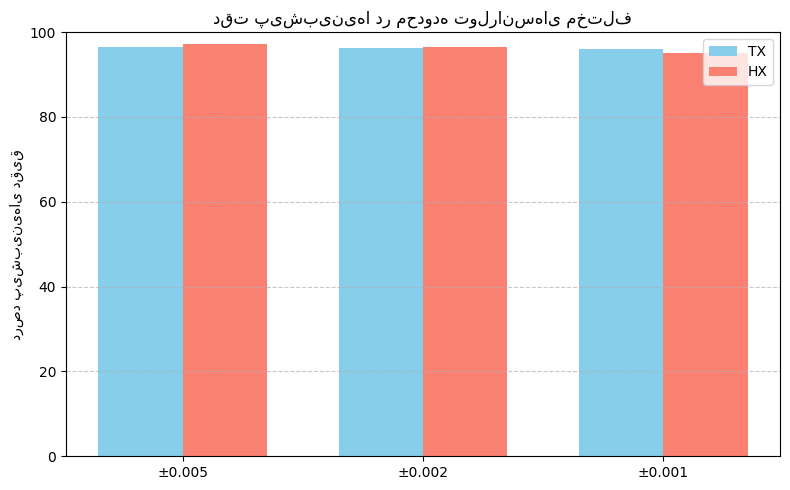

In [24]:
import matplotlib.pyplot as plt
x_labels = [f"±{tol}" for tol in tolerances]
x = np.arange(len(tolerances))

plt.figure(figsize=(8, 5))
bar_width = 0.35

plt.bar(x - bar_width/2, tx_results, width=bar_width, label='TX', color='skyblue')
plt.bar(x + bar_width/2, hx_results, width=bar_width, label='HX', color='salmon')

plt.xticks(x, x_labels)
plt.ylim(0, 100)
plt.ylabel("درصد پیش‌بینی‌های دقیق")
plt.title("دقت پیش‌بینی‌ها در محدوده تولرانس‌های مختلف")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
import shap

d:\ArshadProjectVSCode\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
def model_predict(X_numpy):
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        output = model(X_tensor).cpu().numpy()
    return output

explainer = shap.Explainer(model_predict, x_test)
shap_values = explainer(x_test)

PermutationExplainer explainer: 2532it [01:52, 21.99it/s]                          


C:\Users\sharif\AppData\Local\Temp\ipykernel_20708\3763143634.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,0], x_test, feature_names=df.columns[:-2], show=True)


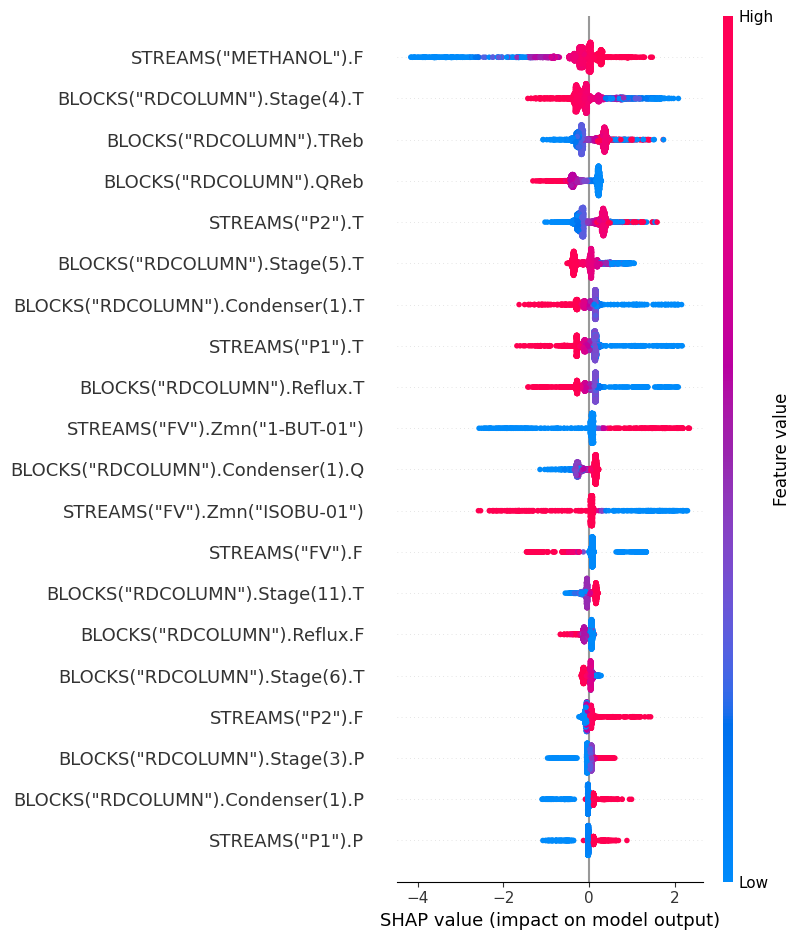

C:\Users\sharif\AppData\Local\Temp\ipykernel_20708\3763143634.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,1], x_test, feature_names=df.columns[:-2], show=True)


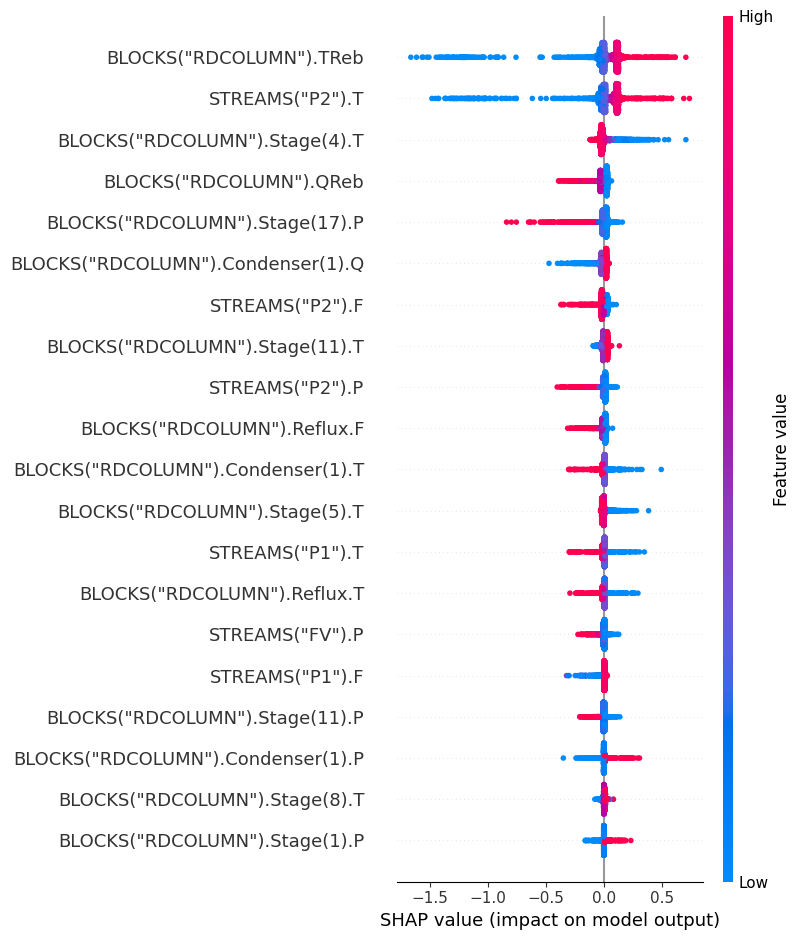

In [27]:
shap.summary_plot(shap_values[:,:,0], x_test, feature_names=df.columns[:-2], show=True)
shap.summary_plot(shap_values[:,:,1], x_test, feature_names=df.columns[:-2], show=True)

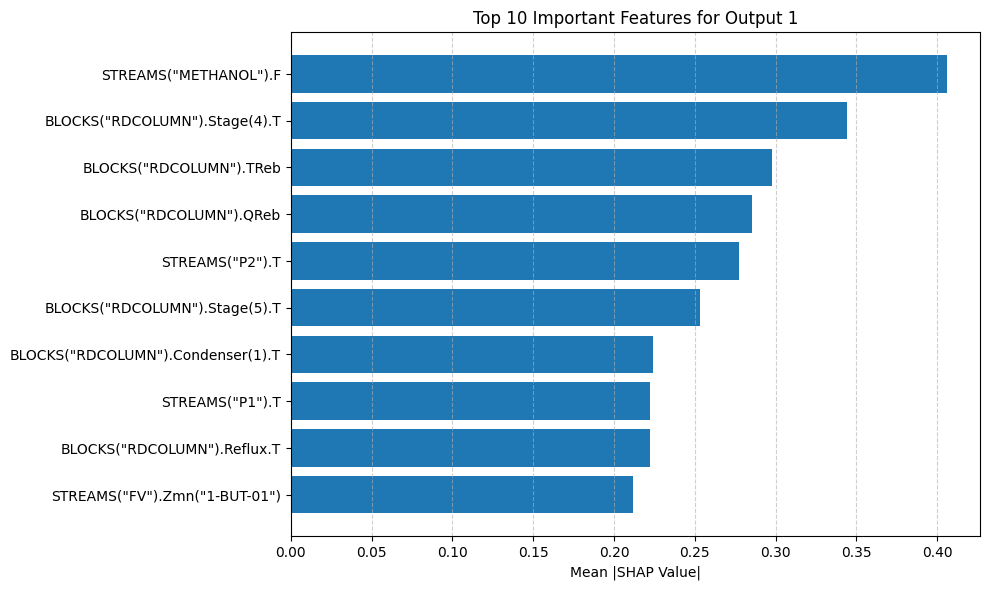

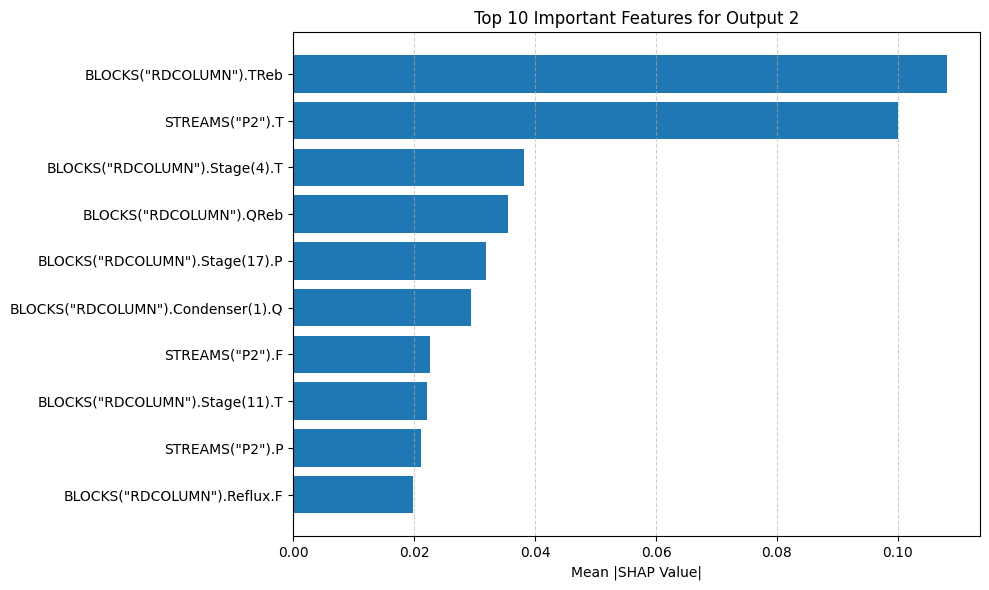

In [28]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = df.columns[:-2]  # چون دو تا خروجی آخر حذف شدن

for output_index in range(2):  # چون دو تا خروجی داریم
    shap_vals = shap_values[:, :, output_index].values
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    top_indices = np.argsort(mean_abs_shap)[::-1][:10]
    top_features = [feature_names[i] for i in top_indices]
    top_values = mean_abs_shap[top_indices]

    plt.figure(figsize=(10, 6))
    plt.barh(top_features[::-1], top_values[::-1])
    plt.xlabel("Mean |SHAP Value|")
    plt.title(f"Top 10 Important Features for Output {output_index + 1}")
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

In [29]:
# 20 ردیف اول از مقادیر واقعی و پیش‌بینی‌شده (مقیاس اصلی)
sample_data = np.hstack([y_true_inv[:20], y_pred_inv[:20]])
columns = ['True_BOT', 'True_DIS', 'Pred_BOT', 'Pred_DIS']
sample_df = pd.DataFrame(sample_data, columns=columns)
print(sample_df.round(6))

    True_BOT  True_DIS  Pred_BOT  Pred_DIS
0   0.937514  0.965668  0.937342  0.965650
1   0.941283  0.727290  0.941348  0.729710
2   0.934364  0.965202  0.934333  0.965072
3   0.936495  0.965974  0.936391  0.965979
4   0.940697  0.960999  0.940572  0.961057
5   0.938933  0.960162  0.938901  0.960119
6   0.938403  0.959168  0.938377  0.959154
7   0.936616  0.965972  0.936568  0.966042
8   0.930501  0.963963  0.930515  0.964040
9   0.937842  0.957837  0.938056  0.957624
10  0.939117  0.960142  0.939075  0.960121
11  0.931341  0.963847  0.931261  0.963805
12  0.938403  0.959168  0.938377  0.959154
13  0.938403  0.959168  0.938377  0.959154
14  0.971196  0.980549  0.971621  0.980608
15  0.968918  0.986473  0.969192  0.986994
16  0.938045  0.955600  0.938062  0.955630
17  0.961098  0.981036  0.960828  0.980853
18  0.936551  0.965980  0.936489  0.966036
19  0.938403  0.959166  0.938377  0.959154


In [30]:
import pandas as pd

results = pd.DataFrame({
    'Actual MoleFractionTX': y_true_inv[:, 0],
    'Predicted MoleFractionTX': y_pred_inv[:, 0],
    'Actual MoleFractionHX': y_true_inv[:, 1],
    'Predicted MoleFractionHX': y_pred_inv[:, 1]
})

Total number of samples: 2531
Plotting first 5000 samples.


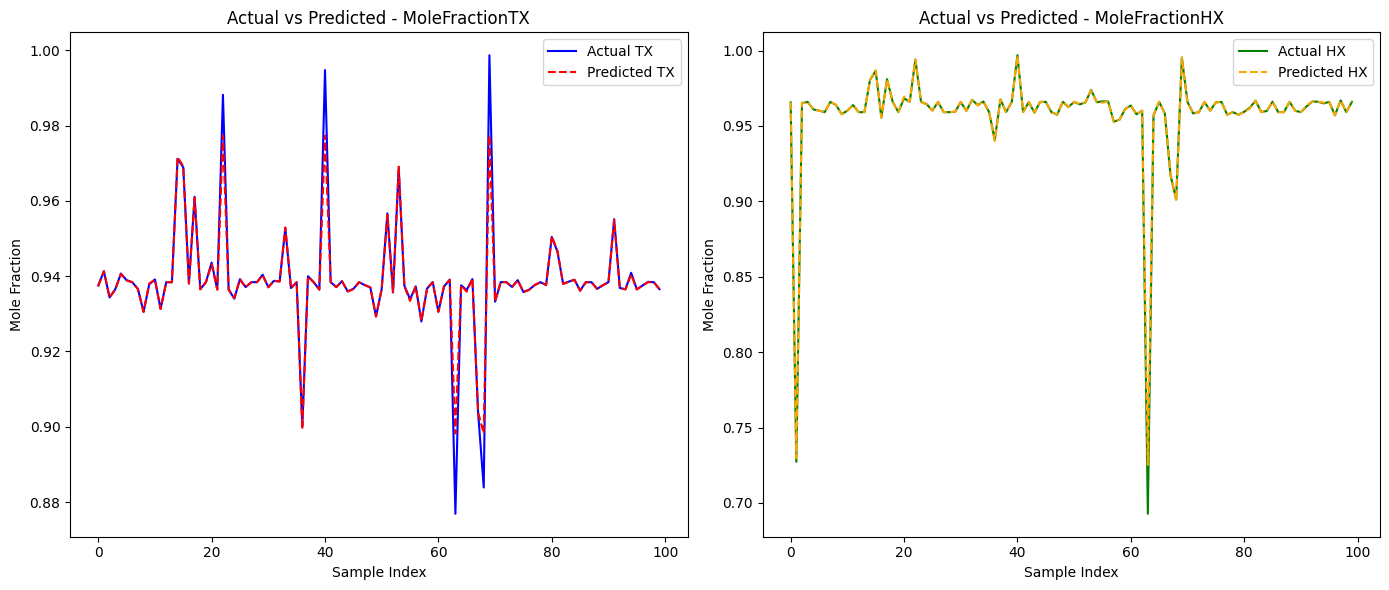

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# بررسی تعداد کل داده‌ها
num_samples = len(results)
print(f"Total number of samples: {num_samples}")

# اگر داده‌ها بیشتر از 5000 بودند، فقط 5000 تای اول را انتخاب کن
if num_samples >= 100:
    subset = results.iloc[:100]
    print("Plotting first 5000 samples.")
else:
    subset = results
    print("Plotting all available samples.")

# رسم نمودار
plt.figure(figsize=(14, 6))

# MoleFractionTX
plt.subplot(1, 2, 1)
plt.plot(subset['Actual MoleFractionTX'].values, label='Actual TX', color='blue')
plt.plot(subset['Predicted MoleFractionTX'].values, label='Predicted TX', color='red', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionTX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

# MoleFractionHX
plt.subplot(1, 2, 2)
plt.plot(subset['Actual MoleFractionHX'].values, label='Actual HX', color='green')
plt.plot(subset['Predicted MoleFractionHX'].values, label='Predicted HX', color='orange', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionHX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

plt.tight_layout()
plt.show()